In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df = pd.read_csv("cleaned_online_sales_data.csv")

# Convert 'Order Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Set style for plots
sns.set_style("whitegrid")

### Top sellers

<Figure size 1000x600 with 0 Axes>

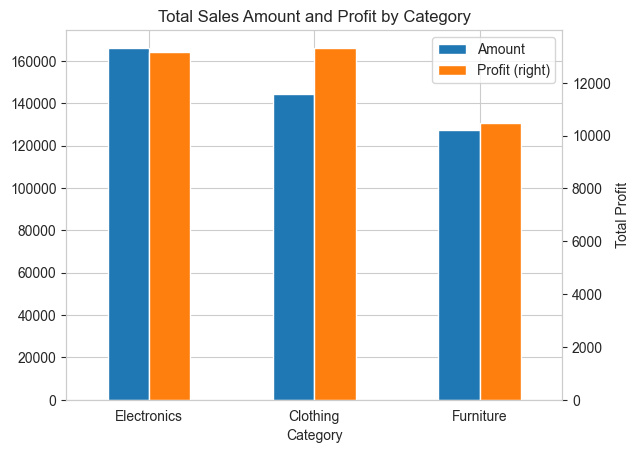

In [100]:
# 1. Sales and Profit by Category (Bar Chart)
category_summary = df.groupby('Category')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 6))
category_summary[['Amount', 'Profit']].plot(kind='bar', secondary_y='Profit', rot=0)
plt.title('Total Sales Amount and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.ylabel('Total Profit')
plt.savefig('sales_profit_by_category.png')
plt.show()
plt.close()

<Figure size 1200x700 with 0 Axes>

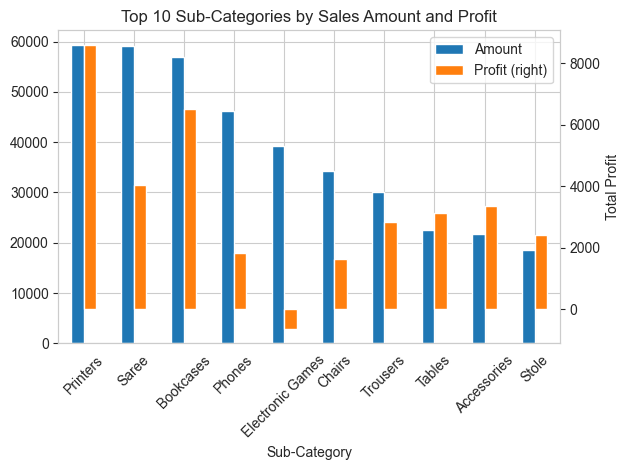

In [101]:
# 2. Sales and Profit by Sub-Category (Top 10 - Bar Chart)
subcategory_summary = df.groupby('Sub-Category')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(12, 7))
subcategory_summary[['Amount', 'Profit']].plot(kind='bar', secondary_y='Profit', rot=45)
plt.title('Top 10 Sub-Categories by Sales Amount and Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Total Amount')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.savefig('sales_profit_by_subcategory.png')
plt.show()
plt.close()

### Geographic Analysis

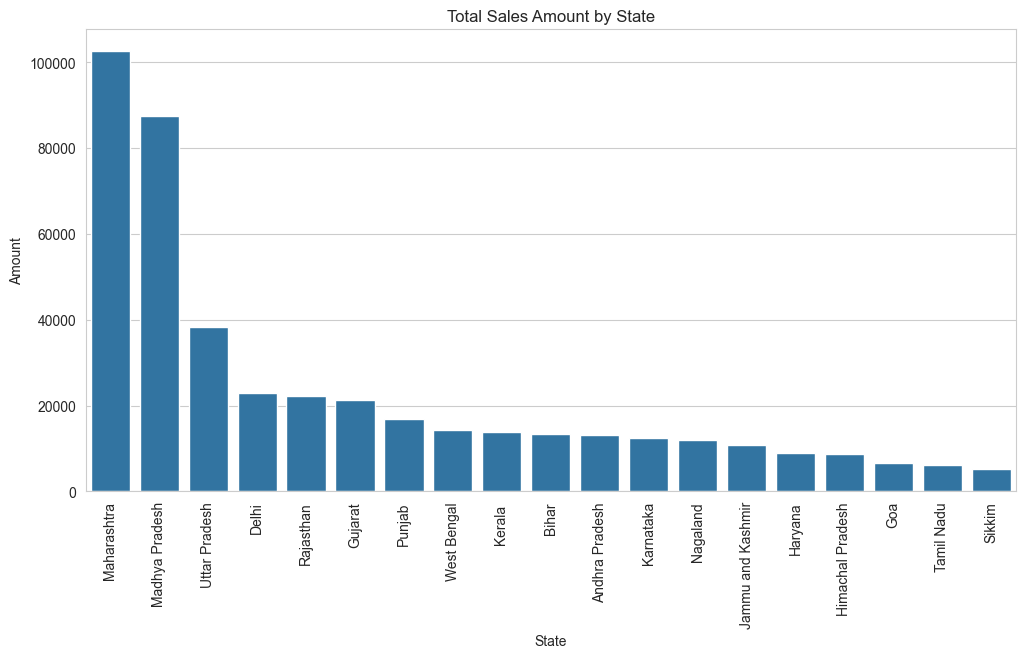

In [102]:
# 3. Top States by Sales Amount (map)
plt.figure(figsize=(12,6))
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False)
sns.barplot(x=state_sales.index, y=state_sales.values)
plt.xticks(rotation=90)
plt.title('Total Sales Amount by State')
plt.ylabel('Amount')
plt.savefig('sales_by_state.png')
plt.show()
plt.close()

### Time Analysis

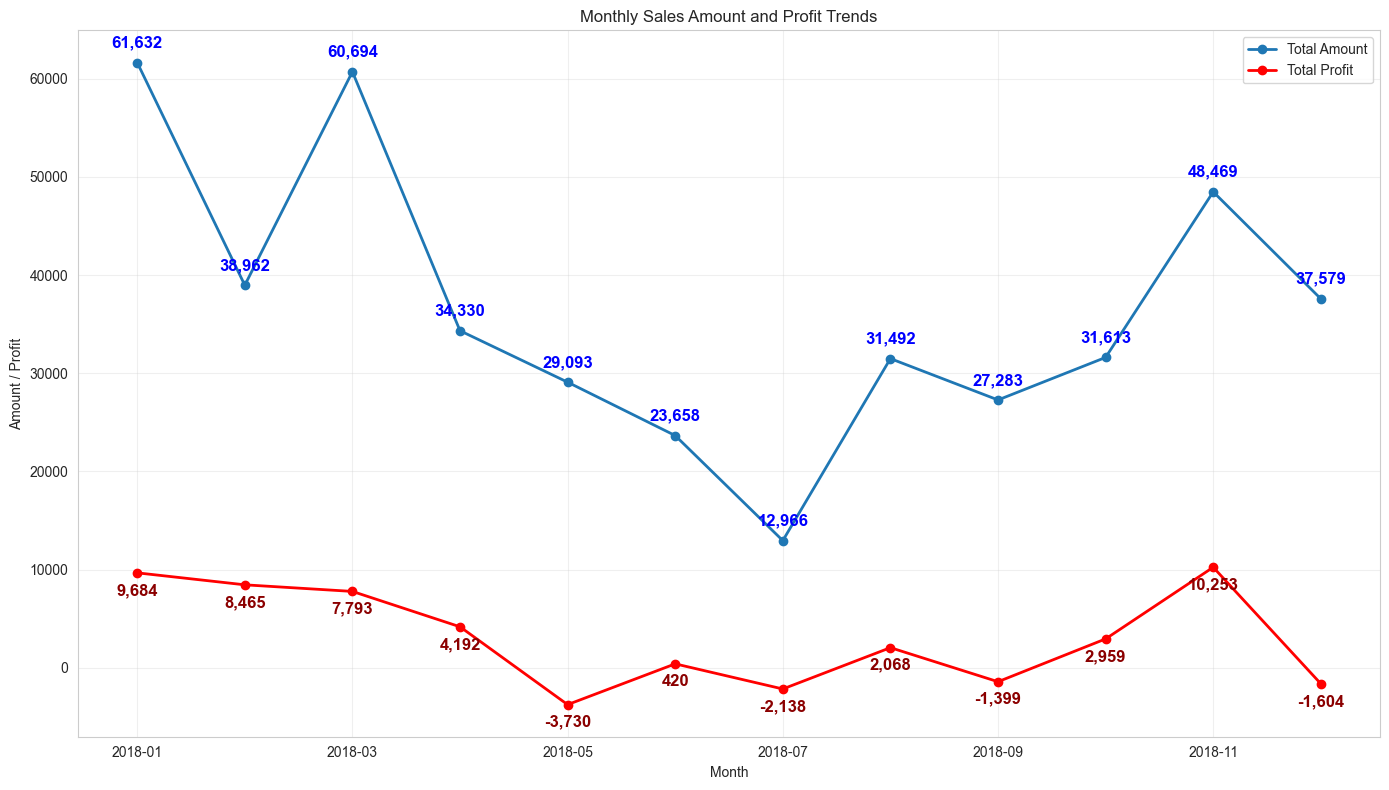

In [103]:
# 4. Monthly Sales and Profit Trends (Line Chart)
df['OrderMonth'] = df['Order Date'].dt.to_period('M')
monthly_trends = df.groupby('OrderMonth')[['Amount', 'Profit']].sum().sort_values(by='OrderMonth')
monthly_trends.index = monthly_trends.index.astype(str)

plt.figure(figsize=(14, 8))

monthly_trends['Amount'].plot(kind='line', marker='o', label='Total Amount', linewidth=2, markersize=6)
monthly_trends['Profit'].plot(kind='line', marker='o', color='red', label='Total Profit', linewidth=2, markersize=6)

for i, (month, amount) in enumerate(monthly_trends['Amount'].items()):
    plt.text(i, amount + max(monthly_trends['Amount'])*0.02, f'{amount:,.0f}', 
            ha='center', va='bottom', fontsize=12, color='blue', fontweight='bold')

for i, (month, profit) in enumerate(monthly_trends['Profit'].items()):
    plt.text(i, profit - max(monthly_trends['Profit'])*0.1, f'{profit:,.0f}', 
            ha='center', va='top', fontsize=12, color='darkred', fontweight='bold')

plt.title('Monthly Sales Amount and Profit Trends')
plt.xlabel('Month')
plt.ylabel('Amount / Profit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('monthly_sales_profit_trends.png')
plt.show()
plt.close()

### costumers & payment methods

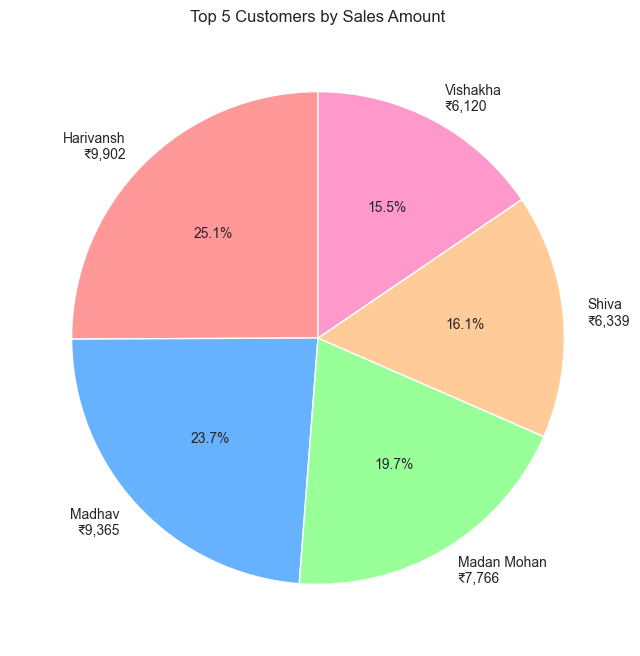

In [104]:
# 5. Most parchases costumers
top_customers = df.groupby("CustomerName")["Amount"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 8))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
plt.pie(top_customers.values, 
        labels=[f'{name}\n₹{amount:,.0f}' for name, amount in zip(top_customers.index, top_customers.values)],
        autopct='%1.1f%%',colors=colors, startangle=90)
plt.title('Top 5 Customers by Sales Amount')
plt.savefig('top_customers.png')
plt.show()
plt.close()

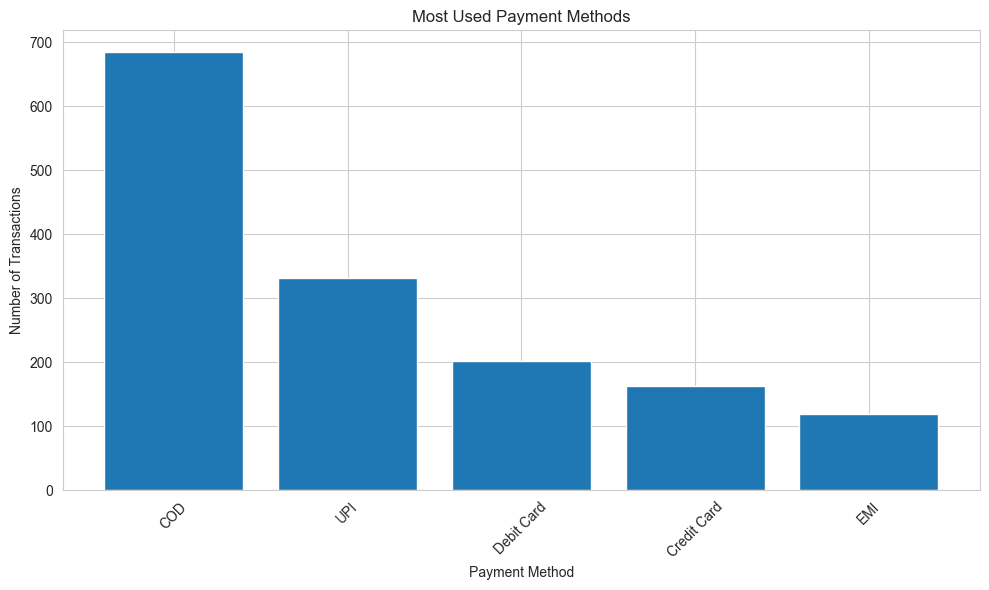

In [105]:
# 6. PAYMENT METHOD USAGE 
payment_count = df["PaymentMode"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(payment_count.index, payment_count.values)
plt.title('Most Used Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('payment_method_usage.png')
plt.show()

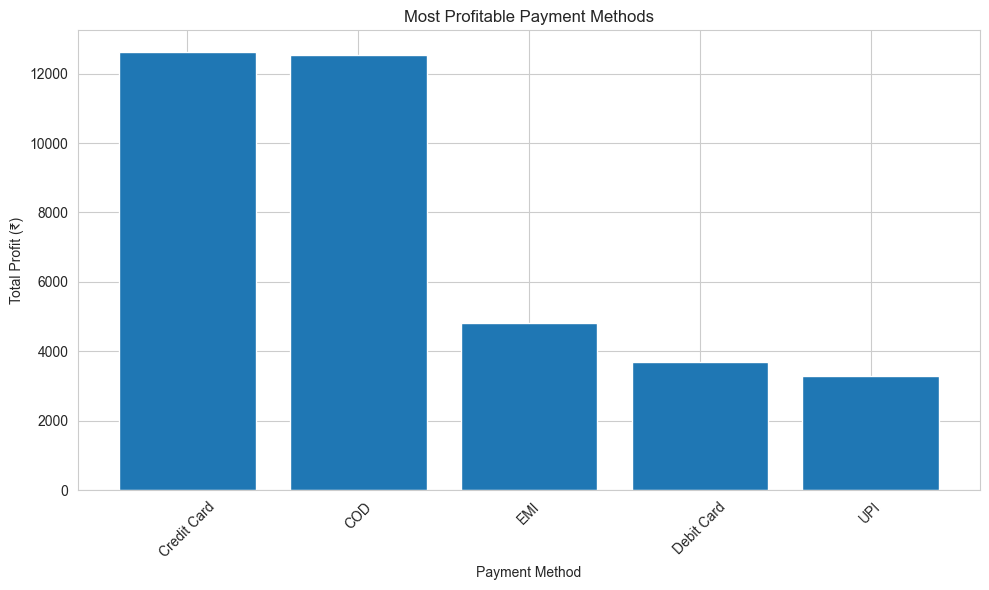

In [106]:
# 7. Most Profitable Payment Methods

payment_profit = df.groupby("PaymentMode")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(payment_profit.index, payment_profit.values)
plt.title('Most Profitable Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Total Profit (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('profitable_payment_methods.png')
plt.show()
plt.close()

### Correlation

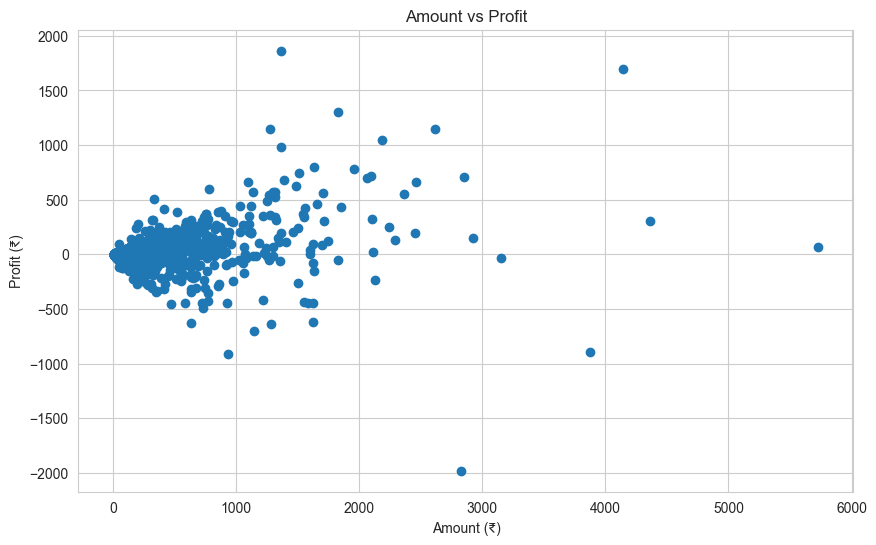

In [ ]:
# 8. Correlation Analysis: Amount vs Profit

plt.figure(figsize=(10, 6))
plt.scatter(df['Amount'], df['Profit'])
plt.xlabel('Amount (₹)')
plt.ylabel('Profit (₹)')
plt.title('Amount vs Profit')
plt.savefig('corr_amount_vs_profit.png')
plt.show()
plt.close()

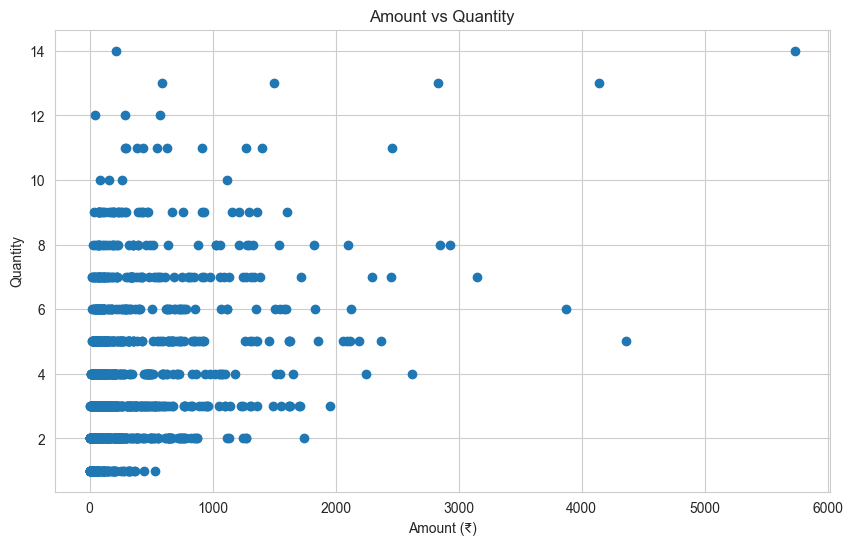

In [ ]:
# 9. Correlation Analysis: Amount vs Quantity

plt.figure(figsize=(10, 6))
plt.scatter(df['Amount'], df['Quantity'])
plt.xlabel('Amount (₹)')
plt.ylabel('Quantity')
plt.title('Amount vs Quantity')
plt.savefig('corr_amount_vs_quantity.png')
plt.show()
plt.close()

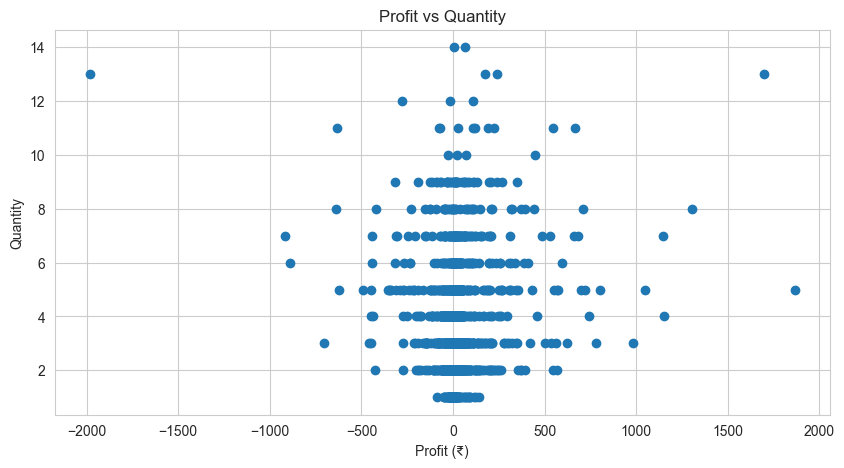

In [ ]:
# 10. Correlation Analysis: Profit vs Quantity

plt.figure(figsize=(10, 5))
plt.scatter(df['Profit'], df['Quantity'])
plt.xlabel('Profit (₹)')
plt.ylabel('Quantity')
plt.title('Profit vs Quantity')
plt.savefig('corr_profit_vs_quantity.png')
plt.show()
plt.close()

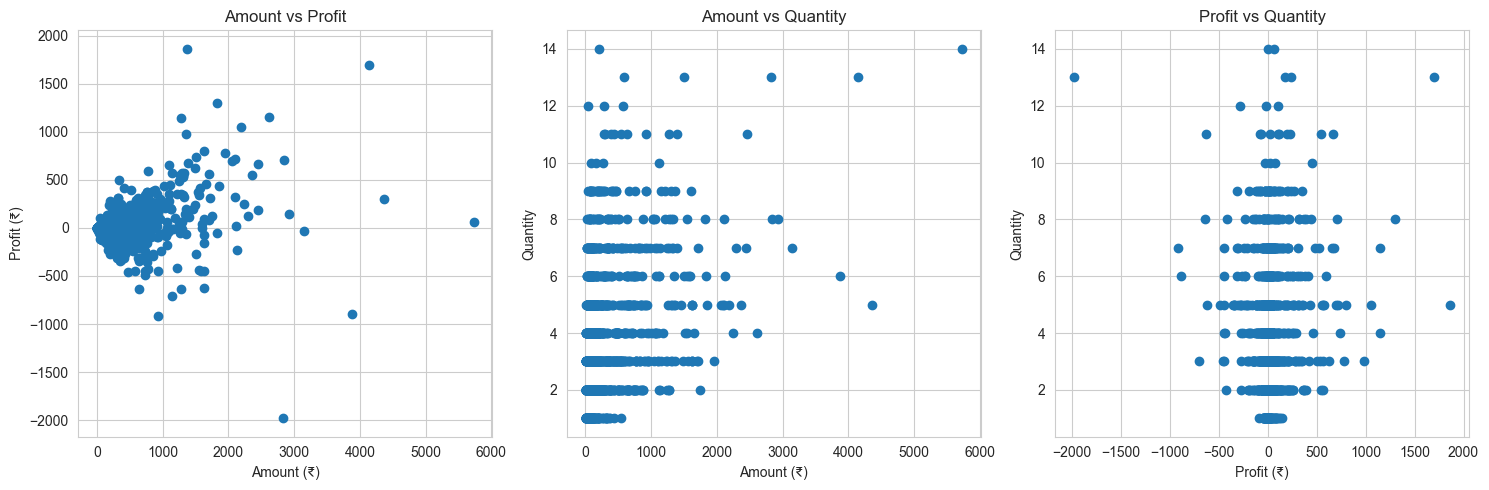

In [ ]:
# 11. Correlation Amount, Profit, Quantity

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['Amount'], df['Profit'])
plt.xlabel('Amount (₹)')
plt.ylabel('Profit (₹)')
plt.title('Amount vs Profit')

plt.subplot(1, 3, 2)
plt.scatter(df['Amount'], df['Quantity'])
plt.xlabel('Amount (₹)')
plt.ylabel('Quantity')
plt.title('Amount vs Quantity')

plt.subplot(1, 3, 3)
plt.scatter(df['Profit'], df['Quantity'])
plt.xlabel('Profit (₹)')
plt.ylabel('Quantity')
plt.title('Profit vs Quantity')

plt.tight_layout()
plt.savefig('correlation_amount_profit_quantity.png')
plt.show()

### profit margins

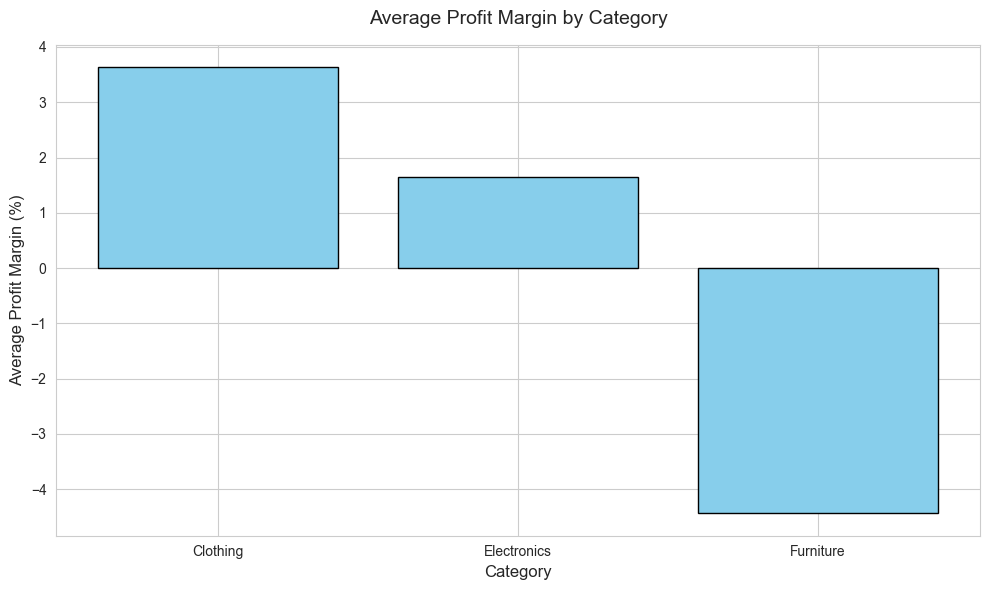

In [ ]:
# 12. Profit Margin by Category

df["Profit_Margin"] = (df["Profit"] / df["Amount"]) * 100
category_profit_margin = df.groupby("Category")["Profit_Margin"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(category_profit_margin.index, category_profit_margin.values, color='skyblue', edgecolor='black')

plt.title('Average Profit Margin by Category', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)

plt.grid(True, axis='y')
plt.tight_layout()

plt.savefig('profit_margin_by_category.png')
plt.show()
plt.close()

### products with -ve profit

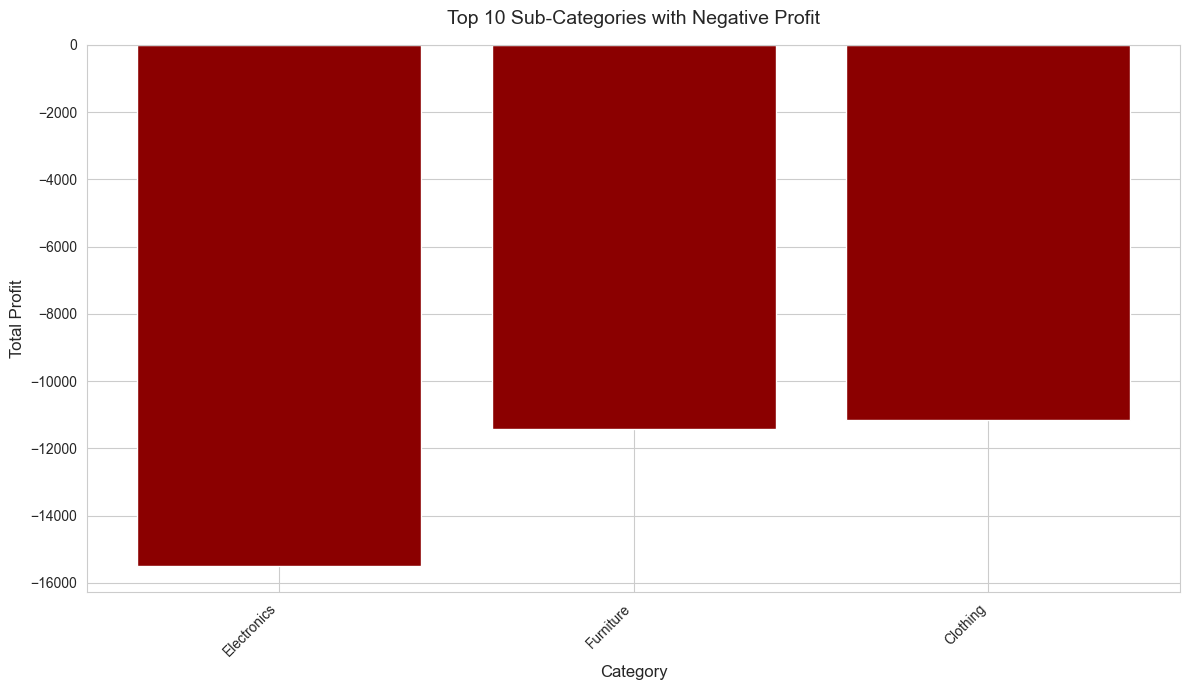

In [ ]:
# 13. category with Negative Profit

negative_profit_items = df[df["Profit"] < 0].groupby(["Category"])[["Amount", "Profit", "Quantity"]].sum().sort_values(by="Profit", ascending=True)

top_10_negative = negative_profit_items.head(10)
labels = [f"{cat}" for cat in top_10_negative.index]

plt.figure(figsize=(12, 7))
plt.bar(labels, top_10_negative["Profit"], color='darkred')

plt.title('Top 10 Sub-Categories with Negative Profit', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

plt.savefig('negative_category_categories.png')
plt.show()
plt.close()

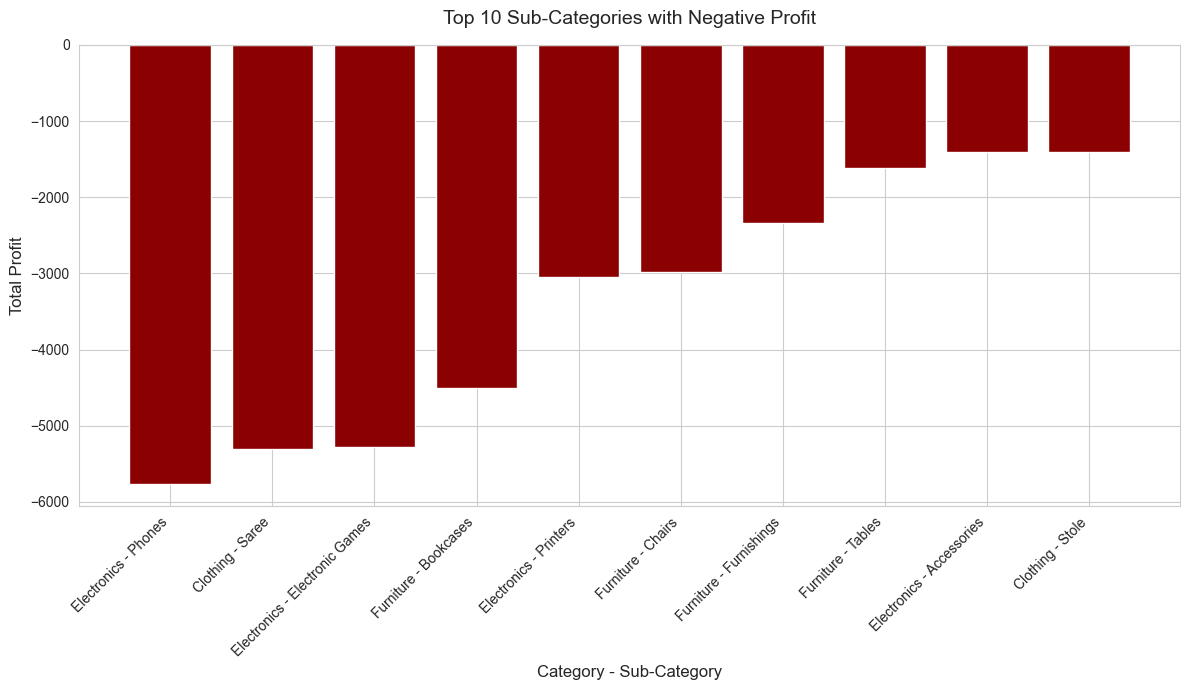

In [ ]:
# 14. sub-category with Negative Profit

negative_profit_items = df[df["Profit"] < 0].groupby(["Category", "Sub-Category"])[["Amount", "Profit", "Quantity"]].sum().sort_values(by="Profit", ascending=True)

top_10_negative = negative_profit_items.head(10)
labels = [f"{cat} - {subcat}" for cat, subcat in top_10_negative.index]

plt.figure(figsize=(12, 7))
plt.bar(labels, top_10_negative["Profit"], color='darkred')

plt.title('Top 10 Sub-Categories with Negative Profit', fontsize=14, pad=15)
plt.xlabel('Category - Sub-Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

plt.savefig('negative_sub-category_subcategories.png')
plt.show()
plt.close()